In [19]:
from scipy import ndimage
import matplotlib.pyplot as plt
import imageio
import PIL
import numpy as np
import cv2
import skimage

Задание на практику.

1.Изучить блокнот.
2.Повторить на других изображениях.
3.Найти еще не менее 3х фильтров, которые применяются для работы с изображениями.
4.Применить найденные фильтры.

In [20]:
!pip install scipy
!pip install  matplotlib
!pip install  imageio
!pip install  pillow
!pip install  numpy
!pip install  scikit-image
!pip install opencv-python
!pip install scikit-learn
!pip install tensorflow
!pip install torchvision

In [21]:
import cv2

In [22]:
image = cv2.imread("https://images.unsplash.com/photo-1573865526739-10659fec78a5?w=600")

 Фильтр Лапласа-выделяет границы объектов, находя области резкого изменения яркости.

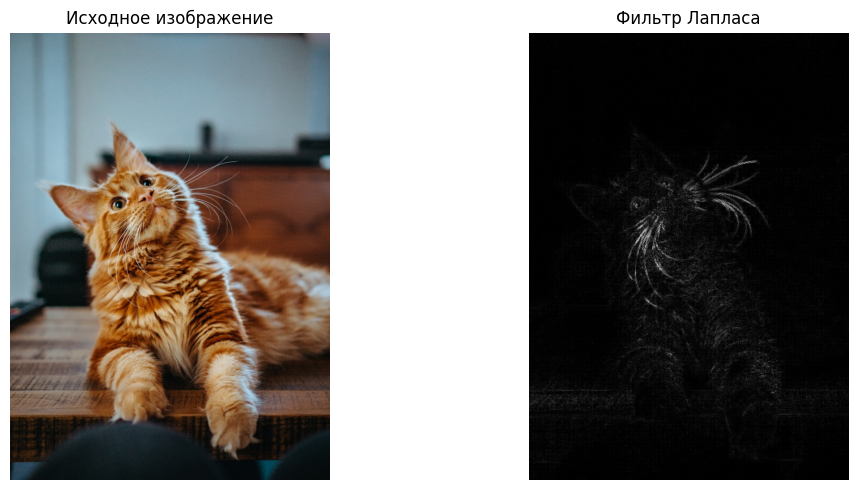

In [23]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import urllib.request

# Функция для отображения результатов
def show_filter_result(original, filtered, title):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(original)
    plt.title('Исходное изображение')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    if len(filtered.shape) == 2:  # Если изображение одноканальное (черно-белое)
        plt.imshow(filtered, cmap='gray')
    else:
        plt.imshow(filtered)
    plt.title(title)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

url = "https://images.unsplash.com/photo-1573865526739-10659fec78a5?w=600"

resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# Конвертируем в RGB ДО использования
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# серый
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# сам фильтр
laplacian = cv2.Laplacian(gray, cv2.CV_64F)
laplacian = np.uint8(np.clip(np.abs(laplacian), 0, 255))

# Теперь image_rgb уже определена
show_filter_result(image_rgb, laplacian, 'Фильтр Лапласа')

Гауссово размытие - сглаживает изображение, размывает мелкие детали

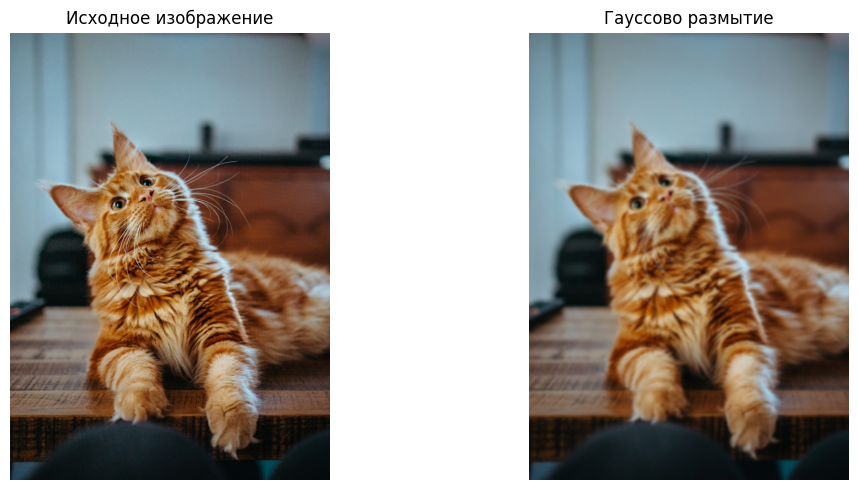

In [24]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import urllib.request

url = "https://images.unsplash.com/photo-1573865526739-10659fec78a5?w=600"

resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# Конвертируем в RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# серый (можно и не использовать, но оставим для совместимости)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# сам фильтр
gaussian_blur = cv2.GaussianBlur(image_rgb, (15, 15), 2)
show_filter_result(image_rgb, gaussian_blur, 'Гауссово размытие')

Фильтр Превитта - выделяет границы объектов

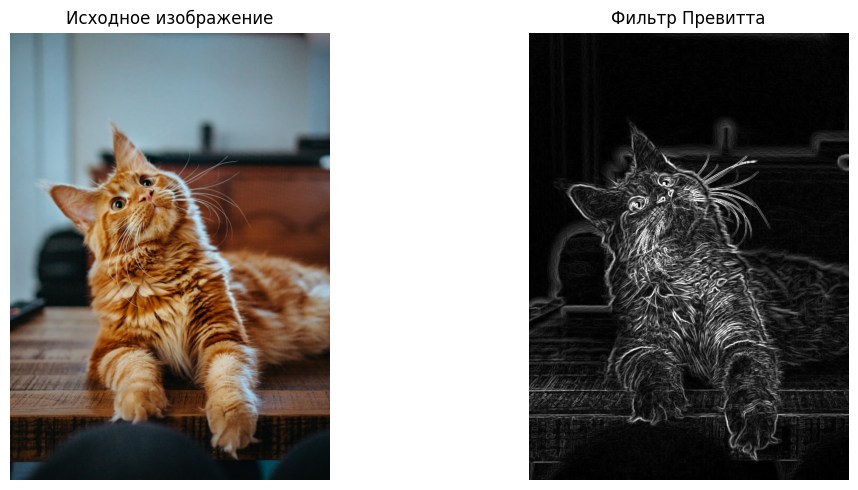

In [25]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import urllib.request

url = "https://images.unsplash.com/photo-1573865526739-10659fec78a5?w=600"

resp = urllib.request.urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)

# Конвертируем в RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# серый
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# ядра Превитта
kernel_prewitt_x = np.array([[-1, 0, 1],
                              [-1, 0, 1],
                              [-1, 0, 1]])

kernel_prewitt_y = np.array([[-1, -1, -1],
                              [ 0,  0,  0],
                              [ 1,  1,  1]])

# Применяем ядра
prewitt_x = cv2.filter2D(gray, cv2.CV_64F, kernel_prewitt_x)
prewitt_y = cv2.filter2D(gray, cv2.CV_64F, kernel_prewitt_y)

# Вычисляем величину градиента
prewitt = np.sqrt(prewitt_x**2 + prewitt_y**2)
prewitt = np.uint8(np.clip(prewitt, 0, 255))

show_filter_result(image_rgb, prewitt, 'Фильтр Превитта')